In [ ]:
# COMP541 organized folder path helper
from pathlib import Path
import os

def _comp541_phase_dir():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == 'code':
        return cwd.parent
    if (cwd / 'Input').exists() and (cwd / 'Output').exists():
        return cwd
    if (cwd.parent / 'Input').exists() and (cwd.parent / 'Output').exists():
        return cwd.parent
    # Fallback for the intended layout: notebook/script is inside a Code folder.
    return cwd.parent if cwd.name.lower() == 'code' else cwd

PHASE_DIR = _comp541_phase_dir()
INPUT_DIR = PHASE_DIR / 'Input'
OUTPUT_DIR = PHASE_DIR / 'Output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('INPUT_DIR :', INPUT_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


## Data Collection , Cleaning and Data Exploration on Climate Weather Data

#### Import Libaries

In [ ]:
import os
import gzip
import json
import time
from datetime import datetime
from collections import defaultdict

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, skew, kurtosis

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False
})

sns.set_palette("tab10")

### Data Collection + Cleaning

#### API Keys using Student Email - Free Tier ( 50K records per day limit )

In [1]:
API_KEY       = "d9b428b28c679f3e0b28937254fb8c90"
YEARLY_URL    = "https://history.openweathermap.org/data/2.5/aggregated/year"
CITY_LIST_URL = "http://bulk.openweathermap.org/sample/city.list.json.gz"

#### Download OWM city master list to cross check lat/long ciities and countries

In [2]:
def load_cities():
    raw = requests.get(CITY_LIST_URL, timeout=120).content
    return json.loads(gzip.decompress(raw))

# country required. names optional: one name or a list.
def filter_cities(cities, country, names=None):
    out = [c for c in cities if c["country"] == country]
    if names:
        names = {names} if isinstance(names, str) else set(names)
        out = [c for c in out if c["name"] in names]
    return out

#### Fetch 365-day stats for one locationCalls OWM API with lat/lon; retries 3x with backoff on timeout

In [3]:
# One call returns all 365 days of statistical data for a location.
# Retries up to 3 times with exponential backoff to handle timeouts.
def get_yearly_aggregation(lat, lon, retries=3):
    params = {"lat": lat, "lon": lon, "appid": API_KEY}
    for attempt in range(retries):
        try:
            r = requests.get(YEARLY_URL, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except (requests.Timeout, requests.ConnectionError):
            if attempt < retries - 1:
                time.sleep(5 * (attempt + 1))   # backoff: 5s, 10s, 15s
                continue
            raise

# Turn one city response into flat rows (one per day).
def flatten_response(city, payload):
    rows = []
    for day_entry in payload.get("result", []):
        row = {
            "city":    city["name"],
            "country": city["country"],
            "lat":     city["coord"]["lat"],
            "lon":     city["coord"]["lon"],
            "month":   day_entry.get("month"),
            "day":     day_entry.get("day"),
        }
        for block_name, block_value in day_entry.items():
            if isinstance(block_value, dict):
                for stat_name, stat_value in block_value.items():
                    row[f"{block_name}_{stat_name}"] = stat_value
        rows.append(row)
    return rows

#### Loop all cities, fetch & flattenCalls the API for each city, pauses 1s between calls, returns one combined DataFrame

In [4]:
# Loop over selected cities, fetch, flatten, return a DataFrame.
# pause=1.0 keeps calls under OWM 60/min rate limit on paid plans.
def build_dataset(selected_cities, pause=1.0):
    all_rows = []
    for city in selected_cities:
        lat, lon = city["coord"]["lat"], city["coord"]["lon"]
        try:
            payload = get_yearly_aggregation(lat, lon)
            all_rows.extend(flatten_response(city, payload))
            print(f"OK   {city['name']} ({city['country']})")
        except requests.HTTPError as e:
            print(f"FAIL {city['name']}: {e}")
        time.sleep(pause)
    return pd.DataFrame(all_rows)

#### Main Function - Accepts city names or (name, lat, lon) tuples; skips OWM download when coords are provided; saves timestamped CSV

In [5]:
# cities entries can be:
#   "CityName"             -> looked up from OWM bulk list
#   ("CityName", lat, lon) -> used directly; skips OWM download if ALL have coords
def run(country, cities=None):
    direct, need_lookup = [], []

    if cities is None:
        need_lookup = None                          # fetch all from OWM
    else:
        entries = [cities] if isinstance(cities, str) else list(cities)
        for entry in entries:
            if isinstance(entry, (list, tuple)) and len(entry) == 3:
                name, lat, lon = entry
                direct.append({"name": name, "country": country,
                                "coord": {"lat": lat, "lon": lon}})
            else:
                need_lookup.append(entry)

    # Only download OWM list when at least one city has no coords
    if need_lookup is None or len(need_lookup) > 0:
        all_cities = load_cities()
        selected = filter_cities(all_cities, country, need_lookup) + direct
    else:
        selected = direct                           # all coords provided -> no download

    print(f"{len(selected)} cities selected\n")
    df = build_dataset(selected)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{country}_yearly_weather_stats_{timestamp}.csv"
    df.to_csv(filename, index=False)
    print(f"\nSaved -> {filename}")
    return df

#### Build yearly city summaryConverts Kelvin→Celsius, flags pleasant/dry/sunny days, rolls up to 1 row per city with weather score

In [6]:
# Return yearly average climate data by city.
# allowed_pairs example: [("Los Angeles", "US"), ("Chicago", "US")]
def clean_and_transform_annual(csv_path, allowed_pairs, out_path=OUTPUT_DIR / "weather_annual.csv"):
    df = pd.read_csv(csv_path)

    keep = pd.MultiIndex.from_tuples(allowed_pairs)
    df = df[pd.MultiIndex.from_arrays([df["city"], df["country"]]).isin(keep)]

    df["temp_c"]   = df["temp_mean"] - 273.15
    df["pleasant"] = ((df["temp_c"] >= 18) & (df["temp_c"] <= 26)).astype(int)
    df["dry"]      = (df["precipitation_mean"] < 1).astype(int)
    df["sunny"]    = (df["clouds_mean"] < 30).astype(int)

    annual = df.groupby(["city", "country", "lat", "lon"], as_index=False).agg(
        temp_c=("temp_c", "mean"),
        precipitation=("precipitation_mean", "mean"),
        humidity=("humidity_mean", "mean"),
        clouds=("clouds_mean", "mean"),
        wind=("wind_mean", "mean"),
        pct_pleasant=("pleasant", "mean"),
        pct_dry=("dry", "mean"),
        pct_sunny=("sunny", "mean"),
    ).round(2)

    pen = ((annual["temp_c"] - 22).abs() / 22       * 0.40 +
           (annual["precipitation"] / 8).clip(0, 1) * 0.25 +
           (annual["clouds"] / 100)                 * 0.20 +
           (annual["humidity"] - 55).abs() / 45     * 0.15)
    annual["weather_score"] = (100 * (1 - pen.clip(0, 1))).round(1)

    annual.to_csv(out_path, index=False)
    print(f"Saved -> {out_path}  ({len(annual)} cities)")
    return annual

#### Build monthly city summarySame as annual but keeps month dimension — 12 rows per city

In [7]:
# Return year + month average climate data by city.
# Output: one row per (city, country, month) — 12 rows per destination.
def clean_and_transform_monthyear(csv_path, allowed_pairs, out_path=OUTPUT_DIR / "weather_monthly.csv"):
    df = pd.read_csv(csv_path)

    keep = pd.MultiIndex.from_tuples(allowed_pairs)
    df = df[pd.MultiIndex.from_arrays([df["city"], df["country"]]).isin(keep)]

    df["temp_c"]   = df["temp_mean"] - 273.15
    df["pleasant"] = ((df["temp_c"] >= 18) & (df["temp_c"] <= 26)).astype(int)
    df["dry"]      = (df["precipitation_mean"] < 1).astype(int)
    df["sunny"]    = (df["clouds_mean"] < 30).astype(int)

    monthly = df.groupby(["city", "country", "lat", "lon", "month"], as_index=False).agg(
        temp_c=("temp_c", "mean"),
        precipitation=("precipitation_mean", "mean"),
        humidity=("humidity_mean", "mean"),
        clouds=("clouds_mean", "mean"),
        wind=("wind_mean", "mean"),
        pct_pleasant=("pleasant", "mean"),
        pct_dry=("dry", "mean"),
        pct_sunny=("sunny", "mean"),
    ).round(2)

    pen = ((monthly["temp_c"] - 22).abs() / 22       * 0.40 +
           (monthly["precipitation"] / 8).clip(0, 1) * 0.25 +
           (monthly["clouds"] / 100)                 * 0.20 +
           (monthly["humidity"] - 55).abs() / 45     * 0.15)
    monthly["weather_score"] = (100 * (1 - pen.clip(0, 1))).round(1)

    monthly.to_csv(out_path, index=False)
    print(f"Saved -> {out_path}  ({len(monthly)} rows)")
    return monthly

#### US Cities refering to Tripadvisor review dataset

In [8]:
CITIES_US = [
    ("Los Angeles",  34.052235, -118.243683),
    ("Austin",       30.266666,  -97.733330),
    ("Baltimore",    39.299236,  -76.609383),
    ("Boston",       42.361145,  -71.057083),
    ("Charlotte",    35.227085,  -80.843124),
    ("Chicago",      41.881832,  -87.623177),
    ("Columbus",     39.983334,  -82.983330),
    ("Dallas",       32.779167,  -96.808891),
    ("Denver",       39.742043, -104.991531),
    ("Detroit",      42.331429,  -83.045753),
    ("Houston",      29.749907,  -95.358421),
    ("Indianapolis", 39.791000,  -86.148003),
    ("Jacksonville", 30.332184,  -81.655647),
    ("Memphis",      35.149349,  -90.057617),
    ("Philadelphia", 39.952583,  -75.165222),
    ("Phoenix",      33.448376, -112.074036),
    ("Seattle",      47.608013, -122.335167),
]

df_us = run("US", CITIES_US)

17 cities selected



NameError: name 'requests' is not defined

In [ ]:
import glob

us_pairs = [(name, "US") for name, lat, lon in CITIES_US]
us_csv   = sorted(glob.glob(str(OUTPUT_DIR / "US_yearly_weather_stats_*.csv")))[-1]
print(f"Using: {us_csv}")

annual_us  = clean_and_transform_annual(us_csv, us_pairs, out_path=OUTPUT_DIR / "US_weather_annual.csv")
monthly_us = clean_and_transform_monthyear(us_csv, us_pairs, out_path=OUTPUT_DIR / "US_weather_monthly.csv")

#### International Cities — 49 airports refering to flight dataset

In [ ]:
CITIES_INTL = [
    ("Paris",            "FR", 49.0097,   2.5477),
    ("London",           "GB", 51.4700,  -0.4543),
    ("Rome",             "IT", 41.7999,  12.2462),
    ("Madrid",           "ES", 40.4719,  -3.5626),
    ("Barcelona",        "ES", 41.2974,   2.0833),
    ("Amsterdam",        "NL", 52.3105,   4.7683),
    ("Athens",           "GR", 37.9364,  23.9445),
    ("Dublin",           "IE", 53.4213,  -6.2701),
    ("Berlin",           "DE", 52.3667,  13.5033),
    ("Lisbon",           "PT", 38.7742,  -9.1342),
    ("Prague",           "CZ", 50.1008,  14.2600),
    ("Vienna",           "AT", 48.1103,  16.5697),
    ("Zurich",           "CH", 47.4647,   8.5492),
    ("Copenhagen",       "DK", 55.6180,  12.6508),
    ("Tokyo",            "JP", 35.7720, 140.3929),  # NRT
    ("Osaka",            "JP", 34.4347, 135.2440),
    ("Seoul",            "KR", 37.4691, 126.4510),
    ("Bangkok",          "TH", 13.6811, 100.7472),
    ("Singapore",        "SG",  1.3644, 103.9915),
    ("Bali",             "ID", -8.7467, 115.1667),
    ("Ho Chi Minh City", "VN", 10.8188, 106.6520),
    ("Hong Kong",        "HK", 22.3080, 113.9185),
    ("Taipei",           "TW", 25.0797, 121.2342),
    ("Dubai",            "AE", 25.2532,  55.3657),
    ("Istanbul",         "TR", 41.2753,  28.7519),
    ("Mexico City",      "MX", 19.4363, -99.0721),
    ("Cancun",           "MX", 21.0365, -86.8771),
    ("Los Cabos",        "MX", 23.1518,-109.7210),
    ("Puerto Vallarta",  "MX", 20.6801,-105.2544),
    ("San Juan",         "US", 18.4394, -66.0018),
    ("Punta Cana",       "DO", 18.5674, -68.3634),
    ("Guatemala City",   "GT", 14.5833, -90.5275),
    ("San Jose",         "CR",  9.9939, -84.2088),
    ("Bogota",           "CO",  4.7016, -74.1469),
    ("Lima",             "PE",-12.0219, -77.1143),
    ("Buenos Aires",     "AR",-34.8222, -58.5358),
    ("Sao Paulo",        "BR",-23.4356, -46.4731),
    ("Rio de Janeiro",   "BR",-22.8099, -43.2505),
    ("Las Vegas",        "US", 36.0840,-115.1537),
    ("New York",         "US", 40.6413, -73.7781),
    ("Miami",            "US", 25.7959, -80.2870),
    ("Orlando",          "US", 28.4312, -81.3081),
    ("Honolulu",         "US", 21.3245,-157.9251),
    ("Vancouver",        "CA", 49.1967,-123.1815),
    ("Toronto",          "CA", 43.6777, -79.6248),
    ("Sydney",           "AU",-33.9399, 151.1753),
    ("Melbourne",        "AU",-37.6690, 144.8410),
    ("Auckland",         "NZ",-37.0082, 174.7850),
    ("Nadi",             "FJ",-17.7554, 177.4431),
]

In [ ]:
# Group by country, run() once per country, combine into one CSV
groups = defaultdict(list)
for name, cc, lat, lon in CITIES_INTL:
    groups[cc].append((name, lat, lon))

dfs = []
for cc, cities in groups.items():
    df = run(cc, cities)
    dfs.append(df)

combined  = pd.concat(dfs, ignore_index=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
intl_csv  = OUTPUT_DIR / f"INTL_yearly_weather_stats_{timestamp}.csv"
combined.to_csv(intl_csv, index=False)
print(f"\nCombined -> {intl_csv}  ({len(combined)} rows, {combined['city'].nunique()} cities)")

In [ ]:
intl_pairs = [(name, cc) for name, cc, lat, lon in CITIES_INTL]

#annual_intl  = clean_and_transform_annual(intl_csv, intl_pairs, out_path=OUTPUT_DIR / "INTL_weather_annual.csv")
monthly_intl = clean_and_transform_monthyear(intl_csv, intl_pairs, out_path=OUTPUT_DIR / "INTL_weather_monthly.csv")

### Data Exploration using Statistical Descriptions

#### Load & Combine Data

In [ ]:
us_raw   = pd.read_csv(INPUT_DIR / "US_weather_monthly.csv",   encoding="latin1")
intl_raw = pd.read_csv(INPUT_DIR / "INTL_weather_monthly.csv", encoding="latin1")

# Combine — no region column; US cities are identified by country == "US"
df = pd.concat([us_raw, intl_raw], ignore_index=True)

month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["month_name"] = df["month"].map(month_map)

# Views used throughout
us_df   = df[df["country"] == "US"].copy()   # US cities only (country code US)
intl_df = df.copy()                           # Everything = "International" view

print(f"Combined shape      : {df.shape}")
print(f"Total cities        : {df['city'].nunique()}")
print(f"US cities           : {us_df['city'].nunique()}  (country == US)")
print(f"International (all) : {intl_df['city'].nunique()}  (all cities)")
print(f"Countries           : {df['country'].nunique()}")
print(f"Null values         : {df.isnull().sum().sum()}")
df.head()

Combined shape      : (792, 15)
Total cities        : 66
US cities           : 23  (country == US)
International (all) : 66  (all cities)
Countries           : 36
Null values         : 0


,city,country,lat,lon,month,temp_c,precipitation,humidity,clouds,wind,pct_pleasant,pct_dry,pct_sunny,weather_score,month_name
0,Austin,US,30.27,-97.73,1,10.33,0.06,65.04,36.66,3.14,0.00,1.0,0.23,67.9,Jan
1,Austin,US,30.27,-97.73,2,12.79,0.05,66.86,43.81,3.72,0.00,1.0,0.00,70.4,Feb
2,Austin,US,30.27,-97.73,3,17.46,0.09,64.57,44.50,3.80,0.42,1.0,0.10,79.4,Mar
3,Austin,US,30.27,-97.73,4,20.39,0.10,68.41,48.08,3.84,0.93,1.0,0.00,82.7,Apr
4,Austin,US,30.27,-97.73,5,24.11,0.17,71.81,46.37,3.53,1.00,1.0,0.00,80.8,May


#### Basic Descriptive Statistics
##### Overall Summary

In [ ]:
NUMERIC = ["temp_c","precipitation","humidity","clouds","wind",
           "pct_pleasant","pct_dry","pct_sunny","weather_score"]

desc = df[NUMERIC].describe().T
desc["midrange"] = (desc["max"] + desc["min"]) / 2
desc["IQR"]      = desc["75%"] - desc["25%"]
desc["skewness"] = df[NUMERIC].skew()
desc["kurtosis"] = df[NUMERIC].kurt()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,midrange,IQR,skewness,kurtosis
temp_c,792.0,17.776,8.193,-4.11,12.230,18.740,24.127,36.70,16.295,11.897,-0.395,-0.551
precipitation,792.0,0.088,0.064,0.00,0.050,0.080,0.120,0.76,0.380,0.070,3.303,25.369
humidity,792.0,71.542,11.200,14.75,67.490,73.345,78.415,88.90,51.825,10.925,-1.847,4.999
clouds,792.0,43.631,13.556,3.52,34.432,44.765,53.425,79.61,41.565,18.992,-0.259,-0.208
wind,792.0,3.647,0.868,1.77,3.018,3.610,4.250,6.88,4.325,1.232,0.264,-0.094
pct_pleasant,792.0,0.345,0.432,0.00,0.000,0.000,0.900,1.00,0.500,0.900,0.647,-1.411
pct_dry,792.0,1.000,0.003,0.94,1.000,1.000,1.000,1.00,0.970,0.000,-19.862,393.490
pct_sunny,792.0,0.187,0.309,0.00,0.000,0.000,0.260,1.00,0.500,0.260,1.578,1.091
weather_score,792.0,71.705,12.307,31.10,65.700,74.200,80.700,95.90,63.500,15.000,-0.856,0.349


##### Central Tendency — Mean, Median, Mode, Midrange

In [ ]:
ct = pd.DataFrame({
    "Mean"    : df[NUMERIC].mean(),
    "Median"  : df[NUMERIC].median(),
    "Mode"    : df[NUMERIC].mode().iloc[0],
    "Midrange": (df[NUMERIC].max() + df[NUMERIC].min()) / 2,
}).round(3)
print(ct.to_string())

                 Mean  Median   Mode  Midrange
temp_c         17.776  18.740  20.39    16.295
precipitation   0.088   0.080   0.06     0.380
humidity       71.542  73.345  72.29    51.825
clouds         43.631  44.765  30.98    41.565
wind            3.647   3.610   3.32     4.325
pct_pleasant    0.345   0.000   0.00     0.500
pct_dry         1.000   1.000   1.00     0.970
pct_sunny       0.187   0.000   0.00     0.500
weather_score  71.705  74.200  77.40    63.500


##### Dispersion — Range, IQR, Variance, Std Dev

In [ ]:
disp = pd.DataFrame({
    "Min"     : df[NUMERIC].min(),
    "Max"     : df[NUMERIC].max(),
    "Range"   : df[NUMERIC].max() - df[NUMERIC].min(),
    "Q1"      : df[NUMERIC].quantile(0.25),
    "Q3"      : df[NUMERIC].quantile(0.75),
    "IQR"     : df[NUMERIC].quantile(0.75) - df[NUMERIC].quantile(0.25),
    "Variance": df[NUMERIC].var(),
    "Std Dev" : df[NUMERIC].std(),
}).round(3)
print(disp.to_string())

                 Min    Max  Range      Q1      Q3     IQR  Variance  Std Dev
temp_c         -4.11  36.70  40.81  12.230  24.127  11.897    67.127    8.193
precipitation   0.00   0.76   0.76   0.050   0.120   0.070     0.004    0.064
humidity       14.75  88.90  74.15  67.490  78.415  10.925   125.451   11.200
clouds          3.52  79.61  76.09  34.432  53.425  18.992   183.768   13.556
wind            1.77   6.88   5.11   3.018   4.250   1.232     0.753    0.868
pct_pleasant    0.00   1.00   1.00   0.000   0.900   0.900     0.186    0.432
pct_dry         0.94   1.00   0.06   1.000   1.000   0.000     0.000    0.003
pct_sunny       0.00   1.00   1.00   0.000   0.260   0.260     0.095    0.309
weather_score  31.10  95.90  64.80  65.700  80.700  15.000   151.464   12.307


##### Five-Number Summary

In [ ]:
five = df[NUMERIC].quantile([0, 0.25, 0.50, 0.75, 1.0]).T
five.columns = ["Min","Q1","Median","Q3","Max"]
five.round(3)

,Min,Q1,Median,Q3,Max
temp_c,-4.11,12.230,18.740,24.127,36.70
precipitation,0.00,0.050,0.080,0.120,0.76
humidity,14.75,67.490,73.345,78.415,88.90
clouds,3.52,34.432,44.765,53.425,79.61
wind,1.77,3.018,3.610,4.250,6.88
pct_pleasant,0.00,0.000,0.000,0.900,1.00
pct_dry,0.94,1.000,1.000,1.000,1.00
pct_sunny,0.00,0.000,0.000,0.260,1.00
weather_score,31.10,65.700,74.200,80.700,95.90


In [ ]:
#### Distribution Properties — Skewness & Kurtosis

In [ ]:
sk = pd.DataFrame({
    "Skewness" : df[NUMERIC].skew(),
    "Kurtosis" : df[NUMERIC].kurt(),
}).round(4)
sk["Skew_Type"] = sk["Skewness"].apply(
    lambda x: "Right-skewed (+)" if x > 0.5
         else "Left-skewed (-)"  if x < -0.5
         else "Approx Normal")
print(sk.to_string())

               Skewness  Kurtosis         Skew_Type
temp_c          -0.3946   -0.5508     Approx Normal
precipitation    3.3032   25.3691  Right-skewed (+)
humidity        -1.8474    4.9993   Left-skewed (-)
clouds          -0.2590   -0.2084     Approx Normal
wind             0.2637   -0.0936     Approx Normal
pct_pleasant     0.6470   -1.4106  Right-skewed (+)
pct_dry        -19.8619  393.4899   Left-skewed (-)
pct_sunny        1.5782    1.0905  Right-skewed (+)
weather_score   -0.8556    0.3491   Left-skewed (-)


#### Class Imbalance Analysis
##### Region Balance

In [ ]:
# Weather score classification target
df["score_class"] = pd.cut(df["weather_score"],
    bins=[0, 40, 60, 80, 100],
    labels=["Poor(<40)","Fair(40-60)","Good(60-80)","Excellent(80+)"])

print("=== US Cities ===")
us_cls = us_df["score_class"].value_counts().sort_index() if "score_class" in us_df.columns else df[df["country"]=="US"]["score_class"].value_counts().sort_index()
us_cls_pct = (us_cls / len(df[df["country"]=="US"]) * 100).round(1)
print(pd.DataFrame({"Count":us_cls,"Pct(%)":us_cls_pct}).to_string())

print("\n=== International (All Cities) ===")
intl_cls = df["score_class"].value_counts().sort_index()
intl_cls_pct = (intl_cls / len(df) * 100).round(1)
print(pd.DataFrame({"Count":intl_cls,"Pct(%)":intl_cls_pct}).to_string())

ratio = intl_cls.max() / max(intl_cls.min(), 1)
print(f"\nImbalance Ratio (majority/minority): {ratio:.2f}x")

=== US Cities ===
                Count  Pct(%)
score_class                  
Poor(<40)           7     2.5
Fair(40-60)        43    15.6
Good(60-80)       144    52.2
Excellent(80+)     82    29.7

=== International (All Cities) ===
                Count  Pct(%)
score_class                  
Poor(<40)          11     1.4
Fair(40-60)       117    14.8
Good(60-80)       452    57.1
Excellent(80+)    212    26.8

Imbalance Ratio (majority/minority): 41.09x


#### Correlation Analysis
######  Pearson Correlation (Numeric)

In [ ]:
corr_matrix = df[NUMERIC].corr(method="pearson").round(3)
print("Top correlations with weather_score:")
top = corr_matrix["weather_score"].drop("weather_score").abs().sort_values(ascending=False)
print(top.to_string())

Top correlations with weather_score:
temp_c           0.733
pct_pleasant     0.688
clouds           0.589
pct_sunny        0.442
humidity         0.310
wind             0.221
precipitation    0.137
pct_dry          0.017


##### Chi-Square Test - Only US Cities vs All Cities (score_class)

In [ ]:
df["group"] = df["country"].apply(lambda x: "US" if x == "US" else "Non-US")
contingency = pd.crosstab(df["group"], df["score_class"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.6f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Interpretation       : {'Significant association (p<0.05)' if p < 0.05 else 'No significant association'}")
print("\nContingency Table:")
print(contingency.to_string())

Chi-Square Statistic : 7.3521
p-value              : 0.061484
Degrees of Freedom   : 3
Interpretation       : No significant association

Contingency Table:
score_class  Poor(<40)  Fair(40-60)  Good(60-80)  Excellent(80+)
group                                                           
Non-US               4           74          308             130
US                   7           43          144              82


#### Data-Type-Specific Descriptions (Tabular)

In [ ]:
CAT_COLS = ["city","country","month_name","score_class"]

print("=== Categorical Feature Cardinality ===")
for col in CAT_COLS:
    print(f"  {col:<15}: {df[col].nunique():>4} unique values")

print("\n=== Unique Value Counts (top 5 each) ===")
for col in CAT_COLS:
    top5 = df[col].value_counts().head(5)
    print(f"\n{col}:")
    print(top5.to_string())

=== Categorical Feature Cardinality ===
  city           :   66 unique values
  country        :   36 unique values
  month_name     :   12 unique values
  score_class    :    4 unique values

=== Unique Value Counts (top 5 each) ===

city:
city
Austin       12
Baltimore    12
Boston       12
Charlotte    12
Chicago      12

country:
country
US    276
MX     48
ES     24
JP     24
CA     24

month_name:
month_name
Jan    66
Feb    66
Mar    66
Apr    66
May    66

score_class:
score_class
Good(60-80)       452
Excellent(80+)    212
Fair(40-60)       117
Poor(<40)          11


#### Data Visualization

##### Line Plot — Monthly Avg Temperature - Only US vs All Cities (Intl)

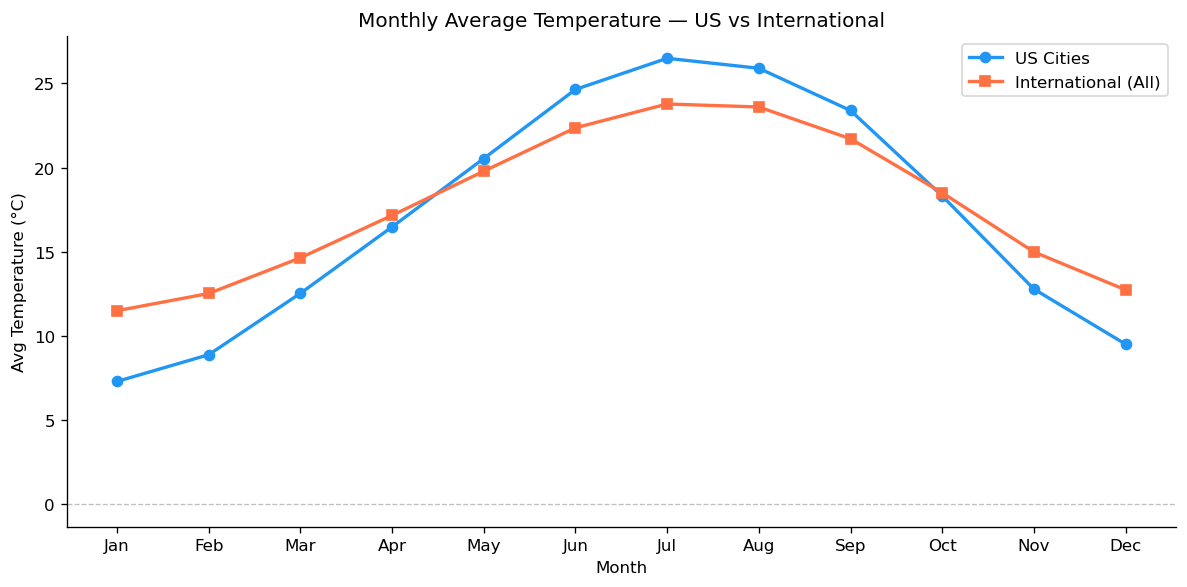

In [ ]:
us_monthly   = df[df["country"]=="US"].groupby("month")["temp_c"].mean()
intl_monthly = df.groupby("month")["temp_c"].mean()

fig, ax = plt.subplots()
ax.plot(us_monthly.index,   us_monthly.values,   marker="o", linewidth=2, label="US Cities",              color="#2196F3")
ax.plot(intl_monthly.index, intl_monthly.values, marker="s", linewidth=2, label="International (All)",     color="#FF7043")

ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_xlabel("Month"); ax.set_ylabel("Avg Temperature (°C)")
ax.set_title("Monthly Average Temperature — US vs International")
ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.5)
ax.legend(); plt.tight_layout(); plt.show()

##### Vertical Bar Plot — Avg Weather Score by City (US)

C:\Users\thant\AppData\Local\Temp\ipykernel_3356\1320509772.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(us_score.index, rotation=45, ha="right")


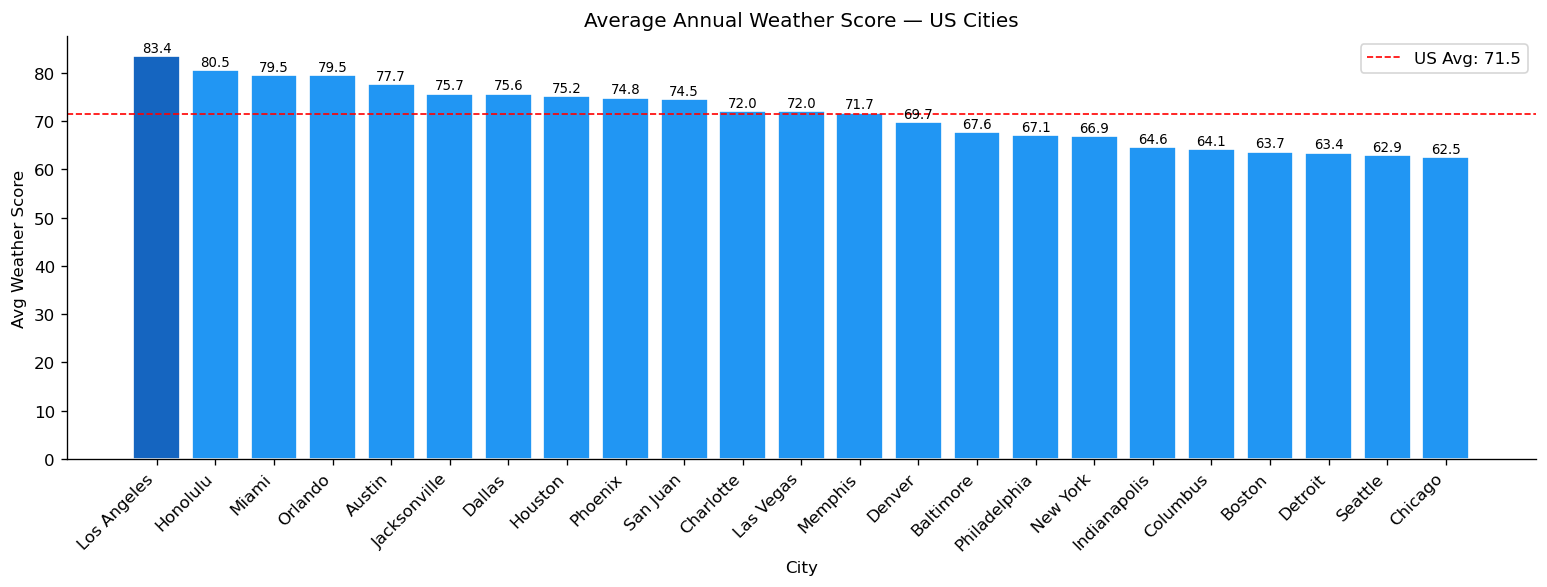

In [ ]:
us_score = (df[df["country"]=="US"]
            .groupby("city")["weather_score"].mean()
            .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ["#1565C0" if i == 0 else "#2196F3" for i in range(len(us_score))]
bars = ax.bar(us_score.index, us_score.values, color=bar_colors, edgecolor="white")
ax.set_xlabel("City"); ax.set_ylabel("Avg Weather Score")
ax.set_title("Average Annual Weather Score — US Cities")
ax.set_xticklabels(us_score.index, rotation=45, ha="right")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
ax.axhline(us_score.mean(), color="red", linestyle="--", linewidth=1, label=f"US Avg: {us_score.mean():.1f}")
ax.legend(); plt.tight_layout(); plt.show()

##### Horizontal Bar Plot — Top 15 INTL Cities by Weather Score

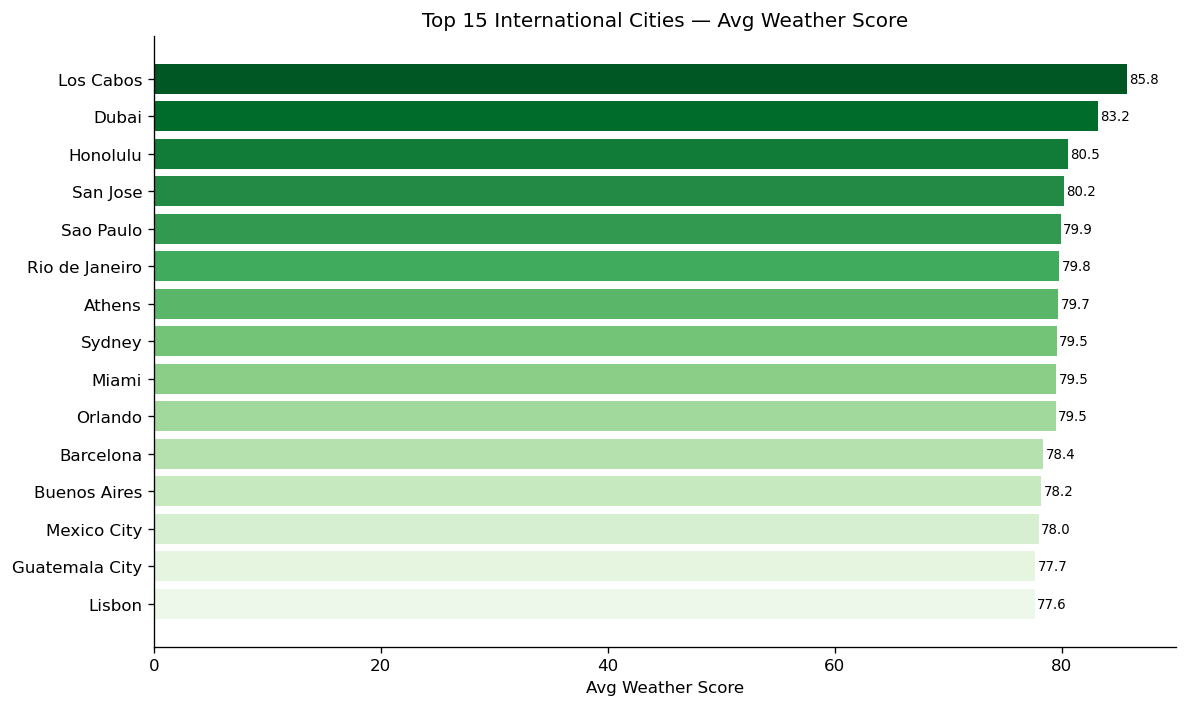

In [ ]:
intl_score = intl.groupby("city")["weather_score"].mean().sort_values().tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(intl_score.index, intl_score.values,
               color=sns.color_palette("Greens", len(intl_score)))
ax.set_xlabel("Avg Weather Score"); ax.set_title("Top 15 International Cities — Avg Weather Score")
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

##### Horizontal Bar Plot — All 66 Cities Ranked by Weather Score

NameError: name 'mpatches' is not defined

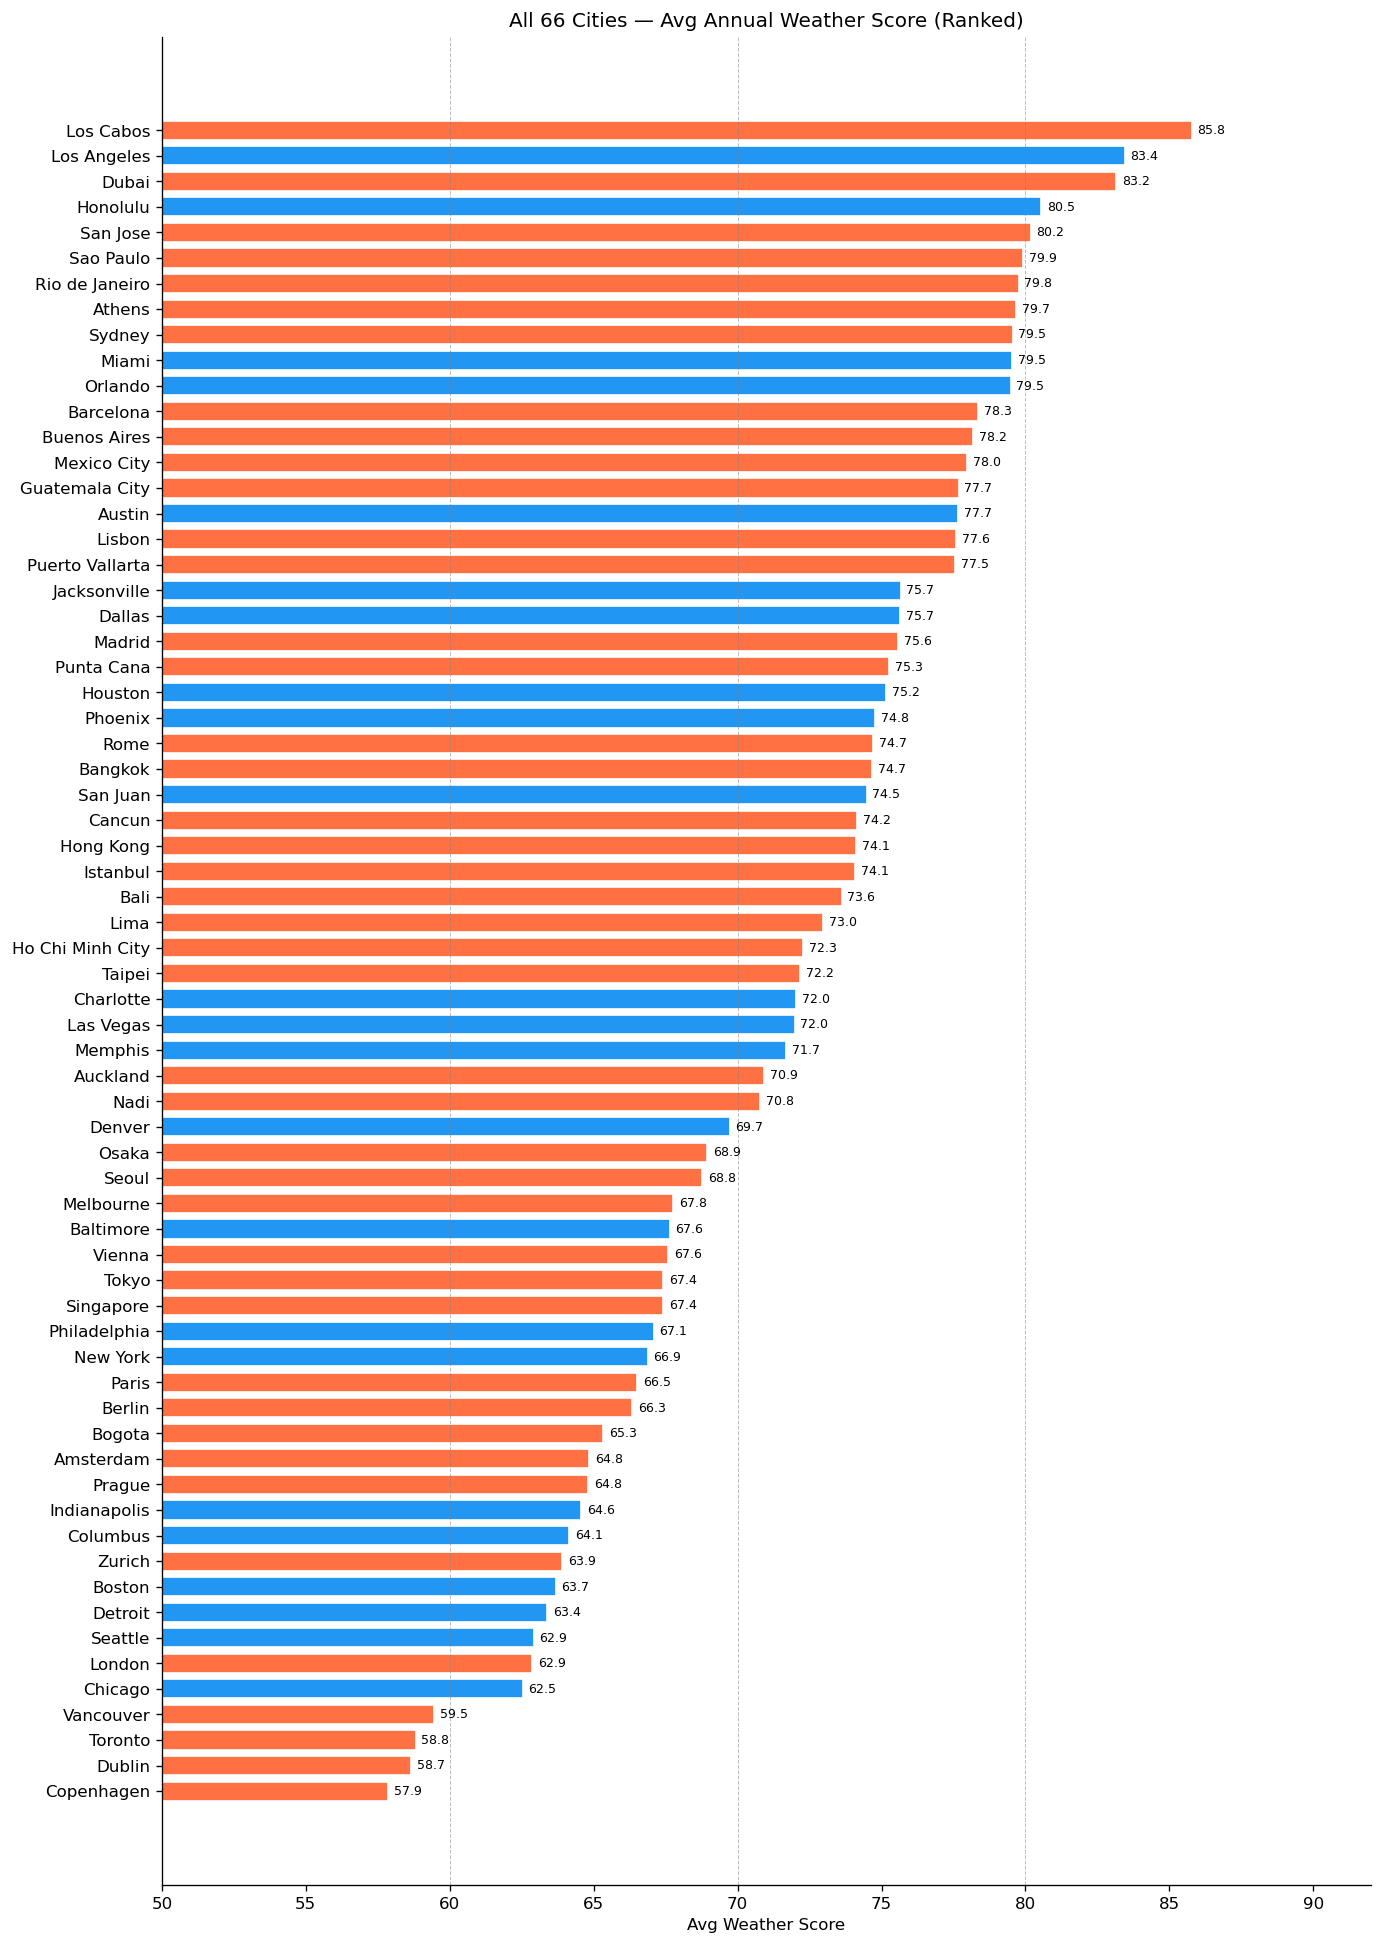

In [ ]:
all_score = (df.groupby(["city","country"])["weather_score"].mean()
             .round(2).reset_index()
             .sort_values("weather_score", ascending=True))

colors = ["#2196F3" if c == "US" else "#FF7043" for c in all_score["country"]]

fig, ax = plt.subplots(figsize=(13, 20))
bars = ax.barh(all_score["city"], all_score["weather_score"], color=colors, edgecolor="white", height=0.75)
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}", va="center", ha="left", fontsize=7.5)
for x in [60, 70, 80]:
    ax.axvline(x, color="gray", linewidth=0.6, linestyle="--", alpha=0.5)

ax.set_xlabel("Avg Weather Score"); ax.set_title("All 66 Cities — Avg Annual Weather Score (Ranked)")
ax.set_xlim(50, 92)
legend_patches = [mpatches.Patch(color="#2196F3", label="US Cities"),
                  mpatches.Patch(color="#FF7043", label="International Cities")]
ax.legend(handles=legend_patches, loc="lower right", fontsize=10)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

##### Histogram — Weather Score Distribution

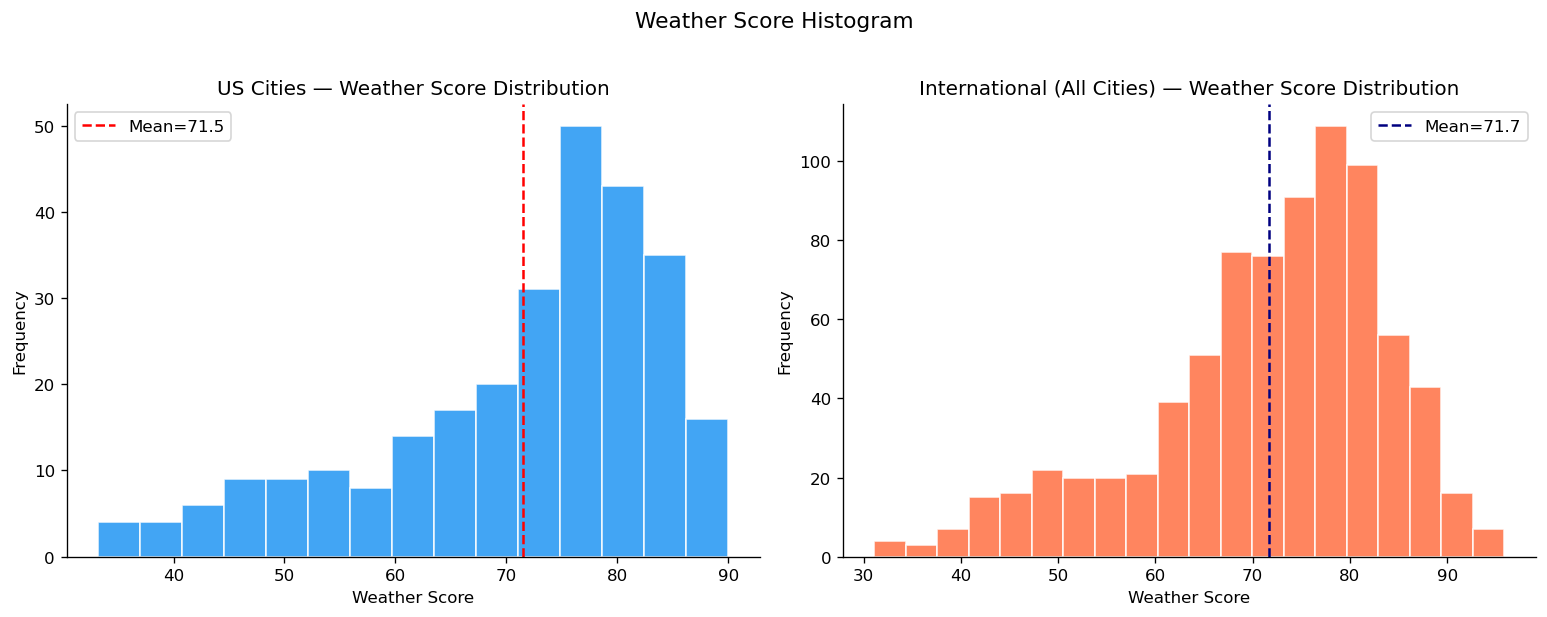

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# US only
us_data = df[df["country"]=="US"]["weather_score"]
axes[0].hist(us_data, bins=15, edgecolor="white", color="#2196F3", alpha=0.85)
axes[0].axvline(us_data.mean(), color="red", linestyle="--", label=f"Mean={us_data.mean():.1f}")
axes[0].set_title("US Cities — Weather Score Distribution")
axes[0].set_xlabel("Weather Score"); axes[0].set_ylabel("Frequency"); axes[0].legend()

# All cities (international)
axes[1].hist(df["weather_score"], bins=20, edgecolor="white", color="#FF7043", alpha=0.85)
axes[1].axvline(df["weather_score"].mean(), color="navy", linestyle="--", label=f"Mean={df['weather_score'].mean():.1f}")
axes[1].set_title("International (All Cities) — Weather Score Distribution")
axes[1].set_xlabel("Weather Score"); axes[1].set_ylabel("Frequency"); axes[1].legend()

plt.suptitle("Weather Score Histogram", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

#####  Pie Plot — Weather Score Class Breakdown

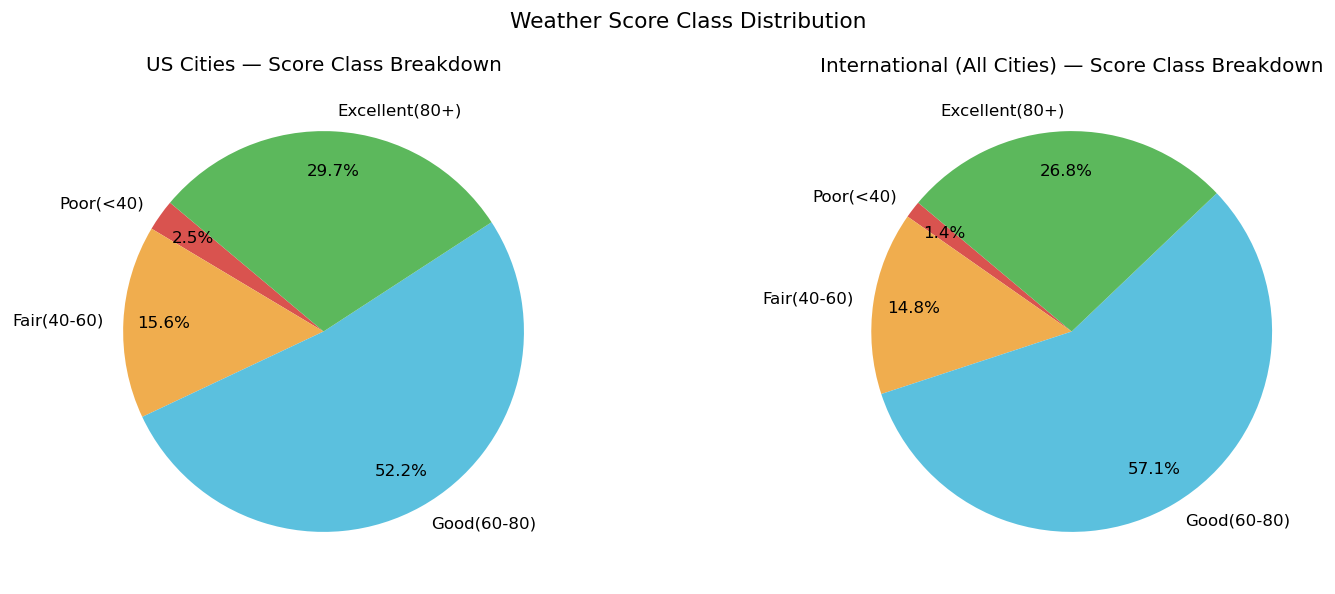

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_pie = ["#d9534f","#f0ad4e","#5bc0de","#5cb85c"]

# US pie
us_cls = df[df["country"]=="US"]["score_class"].value_counts().sort_index()
axes[0].pie(us_cls, labels=us_cls.index, autopct="%1.1f%%",
            startangle=140, colors=colors_pie, pctdistance=0.8)
axes[0].set_title("US Cities — Score Class Breakdown")

# All cities pie
all_cls = df["score_class"].value_counts().sort_index()
axes[1].pie(all_cls, labels=all_cls.index, autopct="%1.1f%%",
            startangle=140, colors=colors_pie, pctdistance=0.8)
axes[1].set_title("International (All Cities) — Score Class Breakdown")

plt.suptitle("Weather Score Class Distribution", fontsize=13)
plt.tight_layout(); plt.show()

##### KDE Density Plot — Temperature Distribution

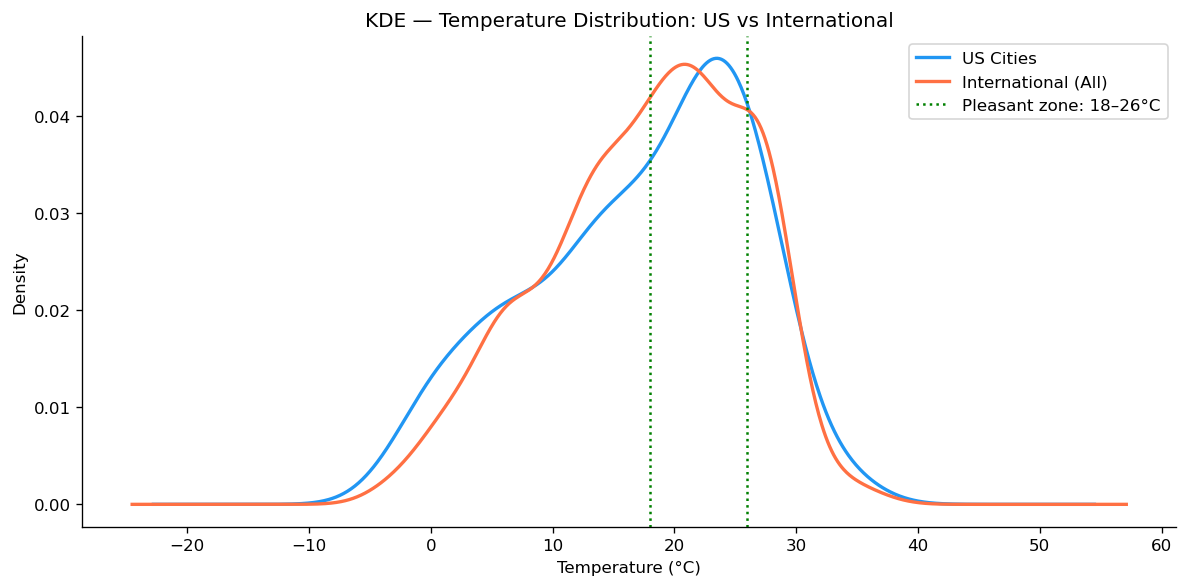

In [ ]:
fig, ax = plt.subplots()
df[df["country"]=="US"]["temp_c"].plot.kde(ax=ax, label="US Cities",           color="#2196F3", linewidth=2)
df["temp_c"].plot.kde(                     ax=ax, label="International (All)",  color="#FF7043", linewidth=2)

ax.set_xlabel("Temperature (°C)")
ax.set_title("KDE — Temperature Distribution: US vs International")
ax.axvline(18, color="green", linestyle=":", label="Pleasant zone: 18–26°C")
ax.axvline(26, color="green", linestyle=":")
ax.legend(); plt.tight_layout(); plt.show()

##### Area Plot — Monthly Avg Precipitation

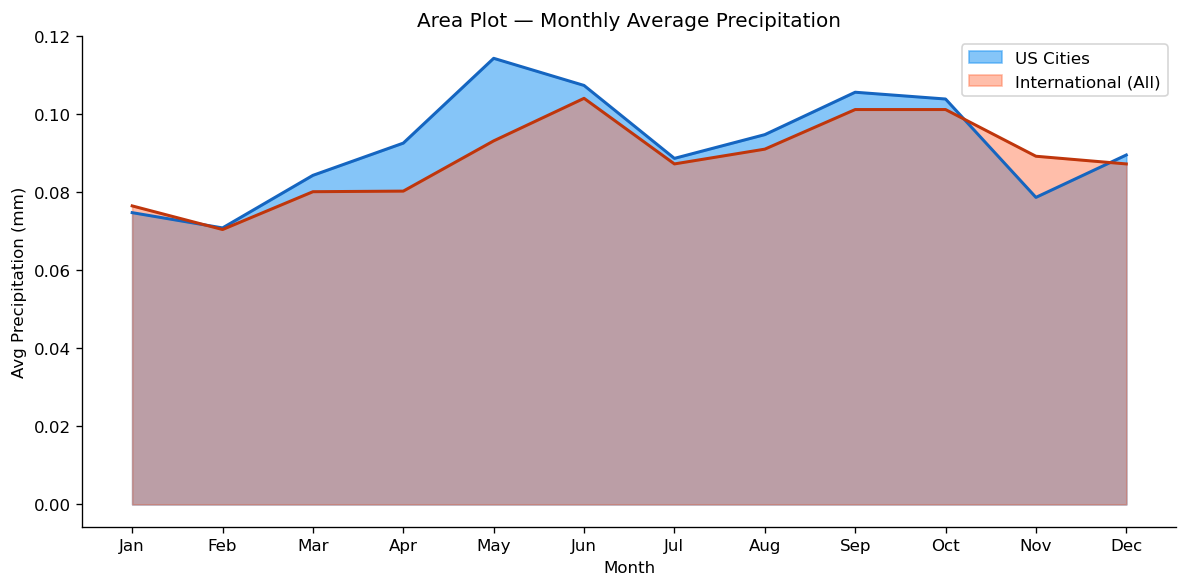

In [ ]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

us_precip   = df[df["country"]=="US"].groupby("month_name")["precipitation"].mean().reindex(month_order)
intl_precip = df.groupby("month_name")["precipitation"].mean().reindex(month_order)

fig, ax = plt.subplots()
x = range(len(month_order))
ax.fill_between(x, us_precip.values,   alpha=0.55, color="#2196F3", label="US Cities")
ax.fill_between(x, intl_precip.values, alpha=0.45, color="#FF7043", label="International (All)")
ax.plot(x, us_precip.values,   color="#1565C0", linewidth=1.8)
ax.plot(x, intl_precip.values, color="#BF360C", linewidth=1.8)
ax.set_xticks(x); ax.set_xticklabels(month_order)
ax.set_xlabel("Month"); ax.set_ylabel("Avg Precipitation (mm)")
ax.set_title("Area Plot — Monthly Average Precipitation")
ax.legend(); plt.tight_layout(); plt.show()

##### Box Plot — Weather Score by Month

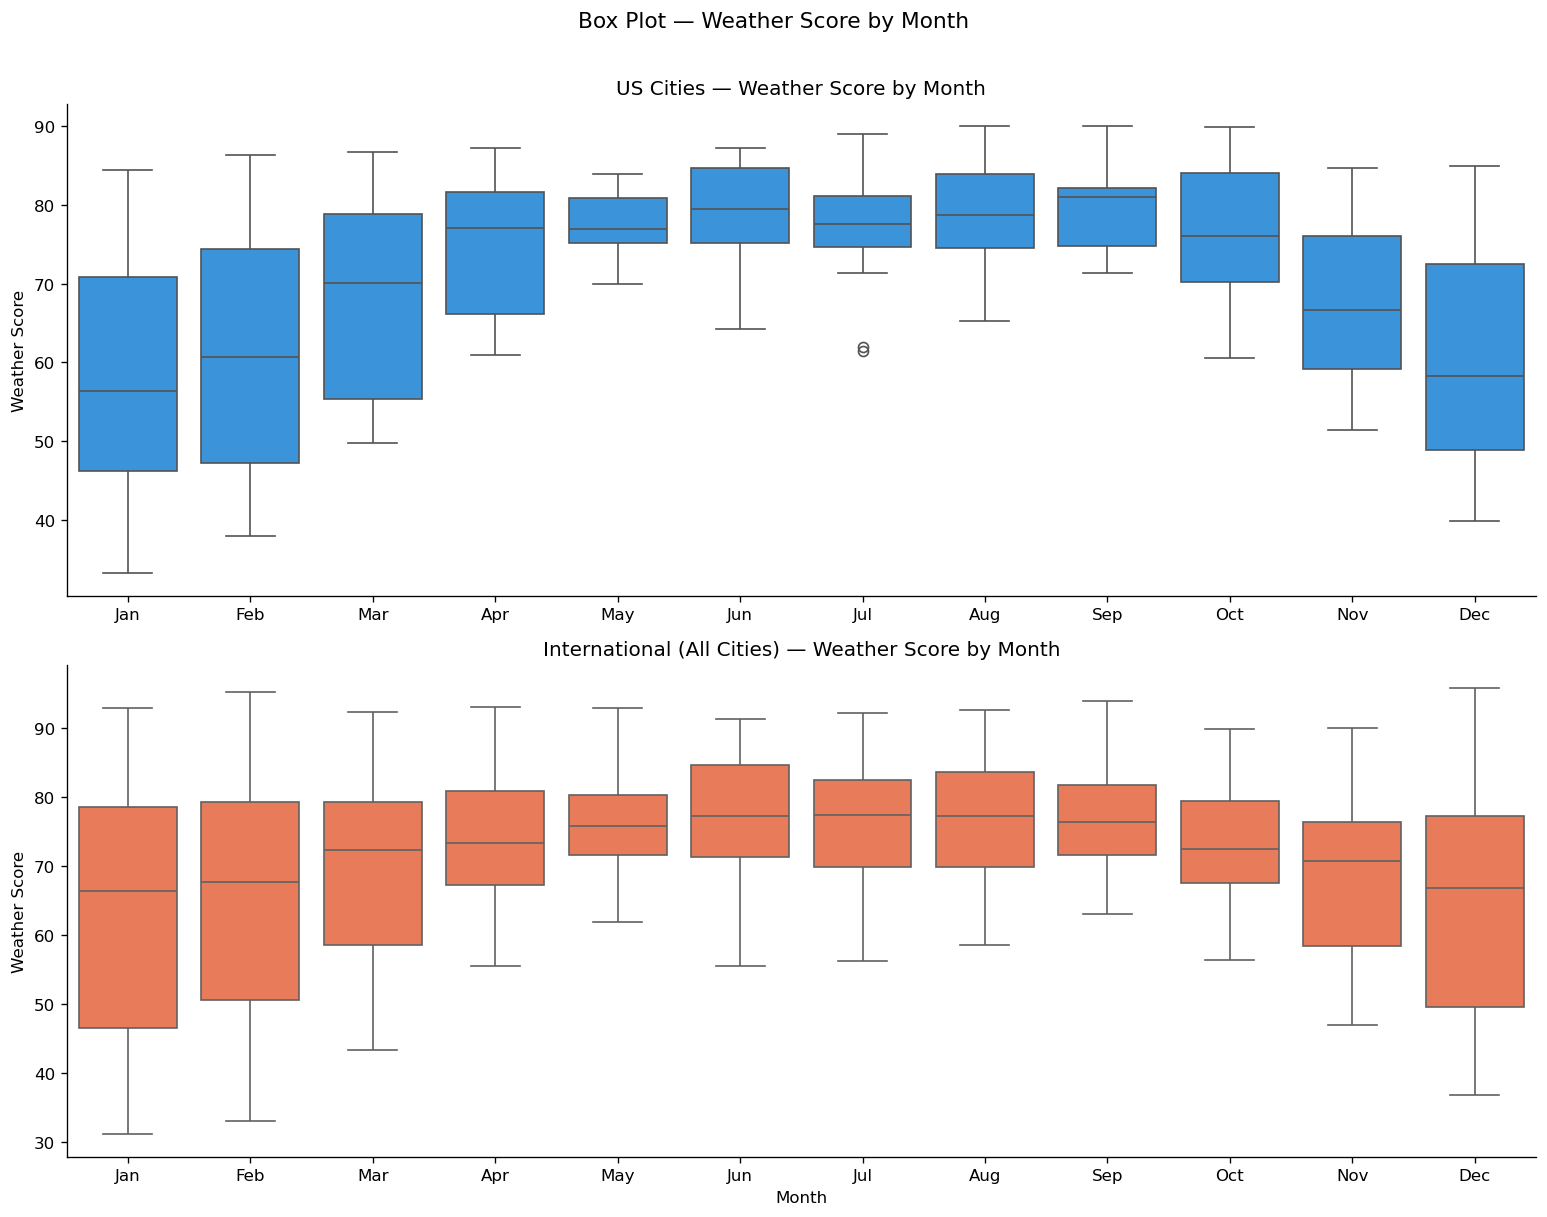

In [ ]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# US only
sns.boxplot(data=df[df["country"]=="US"], x="month_name", y="weather_score",
            order=month_order, ax=axes[0], color="#2196F3")
axes[0].set_title("US Cities — Weather Score by Month")
axes[0].set_xlabel(""); axes[0].set_ylabel("Weather Score")

# All cities
sns.boxplot(data=df, x="month_name", y="weather_score",
            order=month_order, ax=axes[1], color="#FF7043")
axes[1].set_title("International (All Cities) — Weather Score by Month")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Weather Score")

plt.suptitle("Box Plot — Weather Score by Month", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

##### Scatter Plot — Temperature vs Weather Score

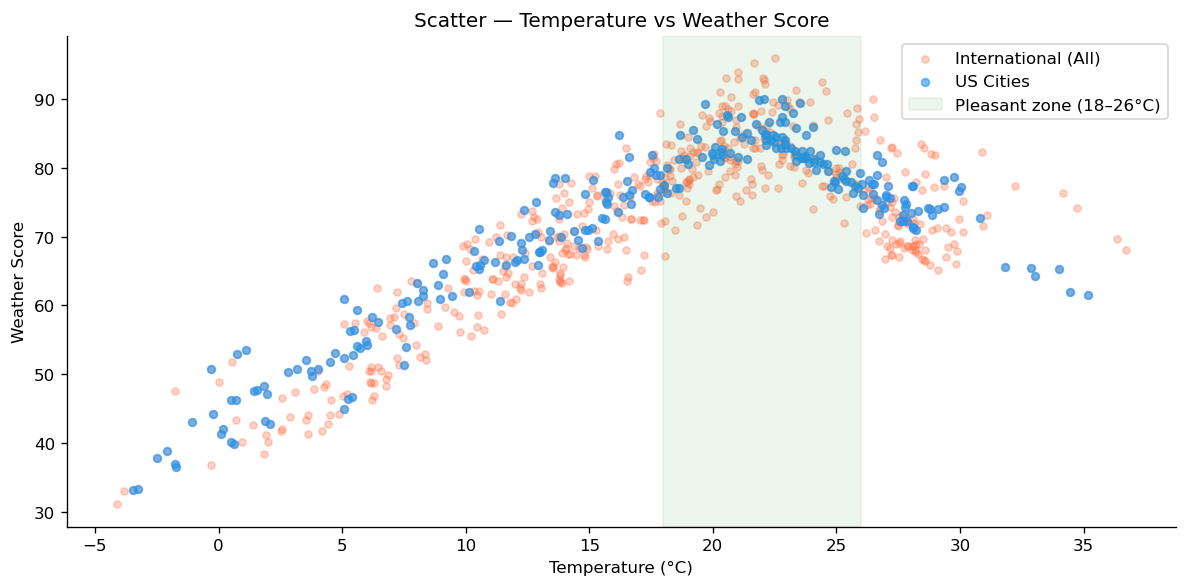

In [ ]:
fig, ax = plt.subplots()
# All cities (international) first so US sits on top
ax.scatter(df["temp_c"], df["weather_score"],
           alpha=0.3, s=18, color="#FF7043", label="International (All)")
ax.scatter(df[df["country"]=="US"]["temp_c"],
           df[df["country"]=="US"]["weather_score"],
           alpha=0.6, s=22, color="#2196F3", label="US Cities")

ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Weather Score")
ax.set_title("Scatter — Temperature vs Weather Score")
ax.axvspan(18, 26, alpha=0.07, color="green", label="Pleasant zone (18–26°C)")
ax.legend(); plt.tight_layout(); plt.show()

##### Hexbin Plot — Humidity vs Weather Score

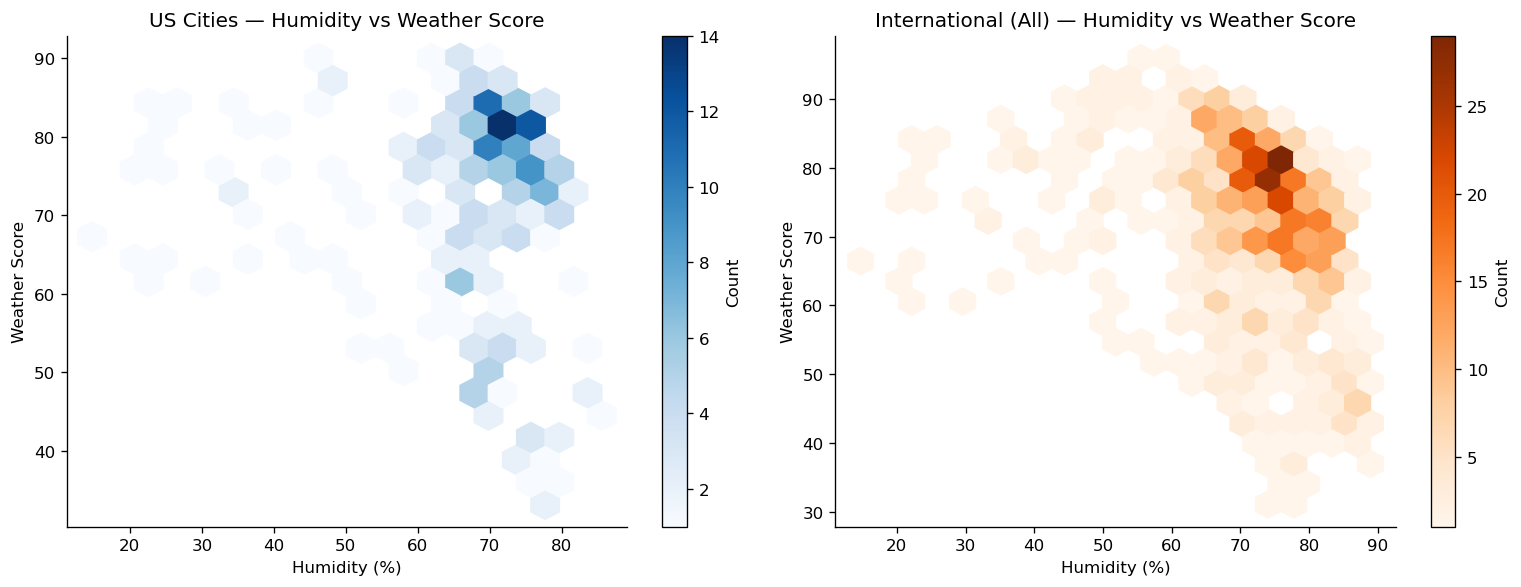

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb1 = axes[0].hexbin(df[df["country"]=="US"]["humidity"],
                     df[df["country"]=="US"]["weather_score"],
                     gridsize=18, cmap="Blues", mincnt=1)
plt.colorbar(hb1, ax=axes[0], label="Count")
axes[0].set_xlabel("Humidity (%)"); axes[0].set_ylabel("Weather Score")
axes[0].set_title("US Cities — Humidity vs Weather Score")

hb2 = axes[1].hexbin(df["humidity"], df["weather_score"],
                     gridsize=20, cmap="Oranges", mincnt=1)
plt.colorbar(hb2, ax=axes[1], label="Count")
axes[1].set_xlabel("Humidity (%)"); axes[1].set_ylabel("Weather Score")
axes[1].set_title("International (All) — Humidity vs Weather Score")

plt.tight_layout(); plt.show()

##### Correlation Matrix Heatmap

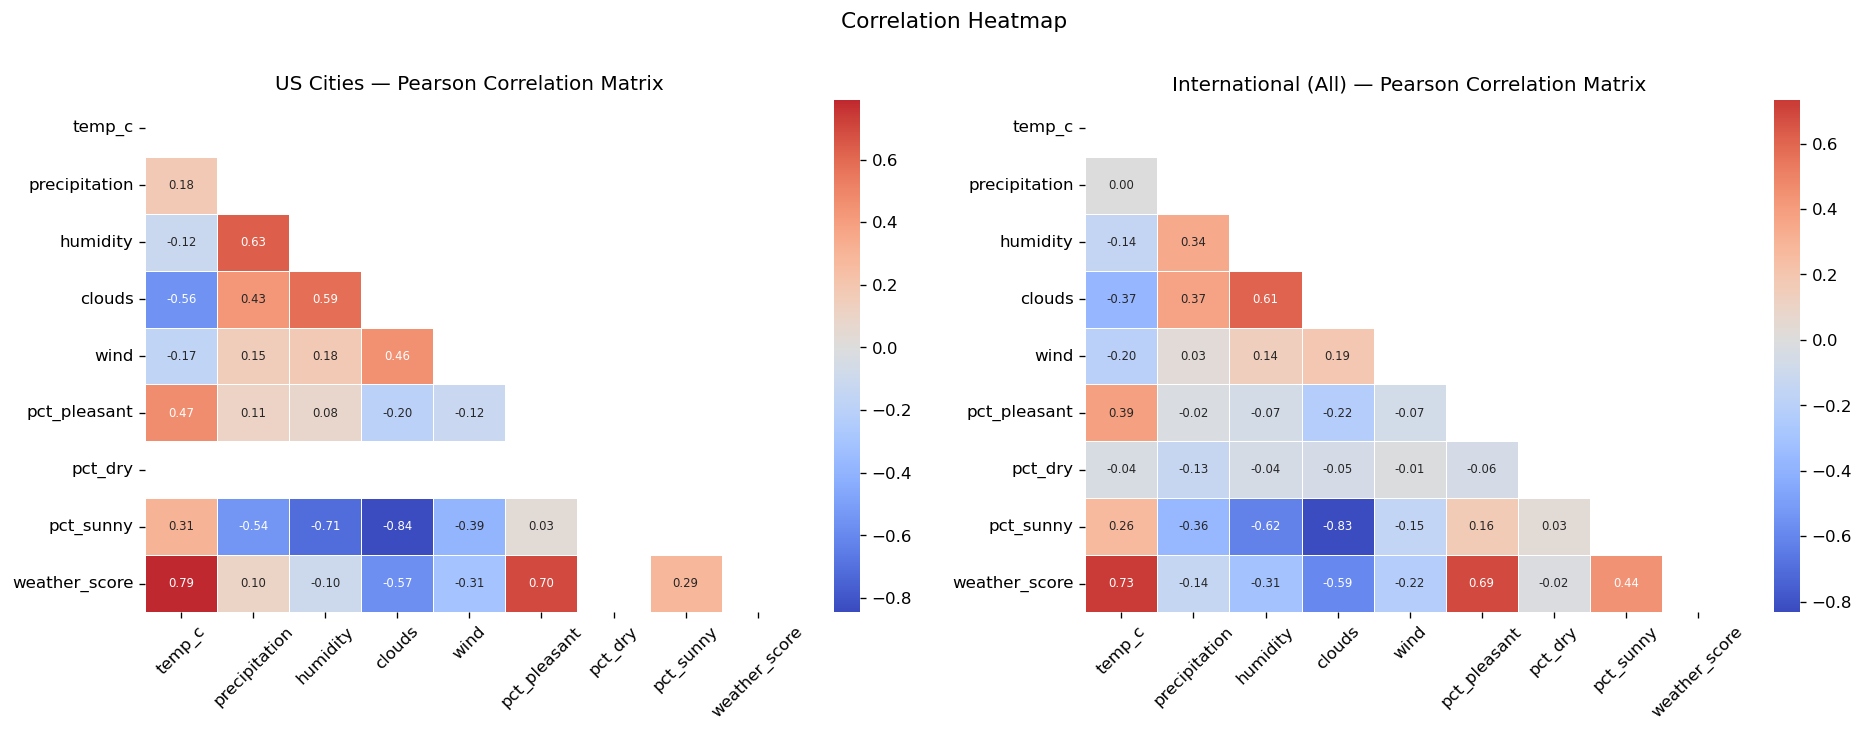

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, data) in zip(axes, [
        ("US Cities",            df[df["country"]=="US"]),
        ("International (All)",  df)]):
    corr = data[NUMERIC].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, ax=ax, annot_kws={"size":7})
    ax.set_title(f"{label} — Pearson Correlation Matrix")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Correlation Heatmap", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

#### Key Findings Summary

In [ ]:
us_data  = df[df["country"]=="US"]
all_data = df

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total rows              : {len(df):,}")
print(f"Total cities            : {all_data['city'].nunique()}")
print(f"  US cities             : {us_data['city'].nunique()}")
print(f"  Non-US cities         : {all_data[all_data['country']!='US']['city'].nunique()}")
print(f"Countries               : {df['country'].nunique()}")
print()
print("WEATHER SCORE")
print(f"  US mean               : {us_data['weather_score'].mean():.1f}")
print(f"  International mean    : {all_data['weather_score'].mean():.1f}")
print(f"  Best city             : {all_data.groupby('city')['weather_score'].mean().idxmax()}")
print(f"  Worst city            : {all_data.groupby('city')['weather_score'].mean().idxmin()}")
print(f"  Best US city          : {us_data.groupby('city')['weather_score'].mean().idxmax()}")
print()
print("TEMPERATURE")
print(f"  Hottest month (all)   : {all_data.groupby('month')['temp_c'].mean().idxmax()} ({all_data.groupby('month')['temp_c'].mean().max():.1f}°C)")
print(f"  Coldest month (all)   : {all_data.groupby('month')['temp_c'].mean().idxmin()} ({all_data.groupby('month')['temp_c'].mean().min():.1f}°C)")
print()
print("CLASS IMBALANCE (All Cities)")
print(df["score_class"].value_counts().to_string())
print("=" * 60)

DATASET SUMMARY
Total rows              : 792
Total cities            : 66
  US cities             : 23
  Non-US cities         : 43
Countries               : 36

WEATHER SCORE
  US mean               : 71.5
  International mean    : 71.7
  Best city             : Los Cabos
  Worst city            : Copenhagen
  Best US city          : Los Angeles

TEMPERATURE
  Hottest month (all)   : 7 (23.8°C)
  Coldest month (all)   : 1 (11.5°C)

CLASS IMBALANCE (All Cities)
score_class
Good(60-80)       452
Excellent(80+)    212
Fair(40-60)       117
Poor(<40)          11
